# West-Med CMEMS collection

Collect Copernicus Marine (CMEMS) surface currents over the western
Mediterranean (lon -6 to 20, lat 35 to 45) for **2023-06-15**, then assemble
them onto a common grid.

We select three reanalysis products from collekt's **bundled catalog** by name:

- **GLORYS** (`cmems_glorys_my`) — global total surface currents (`uo`, `vo`)
- **DUACS** (`cmems_duacs_my`) — global geostrophic currents (`ugos`, `vgos`)
- **MEDFS** (`cmems_med_currents_my`) — Mediterranean regional currents (`uo`, `vo`)

The catalog advertises available variables and depth capability; this notebook
selects variables and the surface depth through `DatasetConfig` below.
collekt installs the CMEMS client by default, but downloading needs Copernicus
Marine credentials: run `copernicusmarine login` once, or set
`COPERNICUSMARINE_SERVICE_USERNAME` / `COPERNICUSMARINE_SERVICE_PASSWORD`.
Files are written under `notebooks/cache/` (git-ignored); the first run
downloads, later runs reuse the cache.


In [1]:
from pathlib import Path

import collekt

def _repo_root(marker: str = "pyproject.toml") -> Path:
    """Anchor the cache to the repo root, whatever the kernel's working dir."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    return here


OUTPUT_ROOT = _repo_root() / "notebooks" / "cache" / "westmed_cmems"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

## Select datasets

`DatasetConfig` names the exact bundled datasets to fetch and carries the provider
parameters for each one, such as variable names and CMEMS depth ranges. Runtime
state such as the notebook cache directory is passed to `Fetcher`.


In [2]:
config = collekt.DatasetConfig(
    collekt.CMEMS("cmems_glorys_my", variables=["uo", "vo"], depth=[1.0, 1.1]),
    collekt.CMEMS("cmems_duacs_my", variables=["ugos", "vgos"]),
    collekt.CMEMS("cmems_med_currents_my", variables=["uo", "vo"], depth=[1.0, 1.1]),
)
config.as_dict()


{'datasets': [{'provider': 'cmems',
   'key': 'cmems_glorys_my',
   'variables': ['uo', 'vo'],
   'depth': [1.0, 1.1]},
  {'provider': 'cmems',
   'key': 'cmems_duacs_my',
   'variables': ['ugos', 'vgos']},
  {'provider': 'cmems',
   'key': 'cmems_med_currents_my',
   'variables': ['uo', 'vo'],
   'depth': [1.0, 1.1]}]}

## Request and download

The download is cache-aware: already-fetched files are reused. Use
`fetcher.plan()` instead of `download()` to preview the provider requests
without downloading anything.

In [3]:
# Western Mediterranean on June 15th 2023
request = collekt.Request(
    region=collekt.Region.from_bbox((-6.0, 20.0, 35.0, 45.0)),
    start="2023-06-15",
    end="2023-06-15",
    metadata={"region_name": "west-med"}
)

# Fetcher organizes the downloads
fetcher = collekt.Fetcher(
    request=request,
    config=config,
    output_dir=OUTPUT_ROOT,
    progress=lambda source, message: print(f"[{source}] {message}"),
)

# Check whether the download is possible
dry_run = fetcher.plan()
dry_run

Summary(planned=3, downloaded=0, reused=0, skipped=0, failed=0)
manifest: /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/manifest.json
  cmems_glorys_my: planned -> /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/cmems/global/glorys/cmems_glorys_my_20230615_a55e6e20.nc
  cmems_duacs_my: planned -> /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/cmems/global/duacs/cmems_duacs_my_20230615_a55e6e20.nc
  cmems_med_currents_my: planned -> /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/cmems/med/currents/cmems_med_currents_my_20230615_a55e6e20.nc

In [4]:
# Start the download
result = fetcher.download()
result

[cmems_glorys_my] downloading 2023-06-15 from cmems_mod_glo_phy_my_0.083deg_P1D-m


INFO - 2026-07-03T13:52:08Z - Selected dataset version: "202311"
INFO - 2026-07-03T13:52:08Z - Selected dataset part: "default"
INFO - 2026-07-03T13:52:09Z - Total size of the download: 161.33 KB.


[cmems_duacs_my] downloading 2023-06-15 from cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D


INFO - 2026-07-03T13:52:10Z - Selected dataset version: "202411"
INFO - 2026-07-03T13:52:10Z - Selected dataset part: "default"
INFO - 2026-07-03T13:52:11Z - Total size of the download: 147.92 KB.


[cmems_med_currents_my] downloading 2023-06-15 from cmems_mod_med_phy-cur_my_4.2km_P1D-m


INFO - 2026-07-03T13:52:12Z - Selected dataset version: "202511"
INFO - 2026-07-03T13:52:12Z - Selected dataset part: "default"
WARNING - 2026-07-03T13:52:12Z - Some of your subset selection [1.0, 1.1] for the depth dimension exceed the dataset coordinates [1.0182366371154785, 5754.0439453125]
INFO - 2026-07-03T13:52:13Z - Total size of the download: 1.16 MB.


Summary(planned=0, downloaded=3, reused=0, skipped=0, failed=0)
manifest: /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/manifest.json
  cmems_glorys_my: downloaded -> /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/cmems/global/glorys/cmems_glorys_my_20230615_a55e6e20.nc
  cmems_duacs_my: downloaded -> /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/cmems/global/duacs/cmems_duacs_my_20230615_a55e6e20.nc
  cmems_med_currents_my: downloaded -> /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_cmems/20230615_20230615_a55e6e20/cmems/med/currents/cmems_med_currents_my_20230615_a55e6e20.nc

## Inspect native-resolution currents

Before assembling onto a common grid, open each downloaded NetCDF file directly and plot current speed on its native grid.

GLORYS: dims=('latitude', 'longitude'), shape=(121, 313), lat_res=0.0833321°, lon_res=0.0833335°, finite=20879
DUACS: dims=('latitude', 'longitude'), shape=(82, 210), lat_res=0.125°, lon_res=0.125°, finite=9303
MEDFS: dims=('latitude', 'longitude'), shape=(240, 625), lat_res=0.0416679°, lon_res=0.0416665°, finite=76395


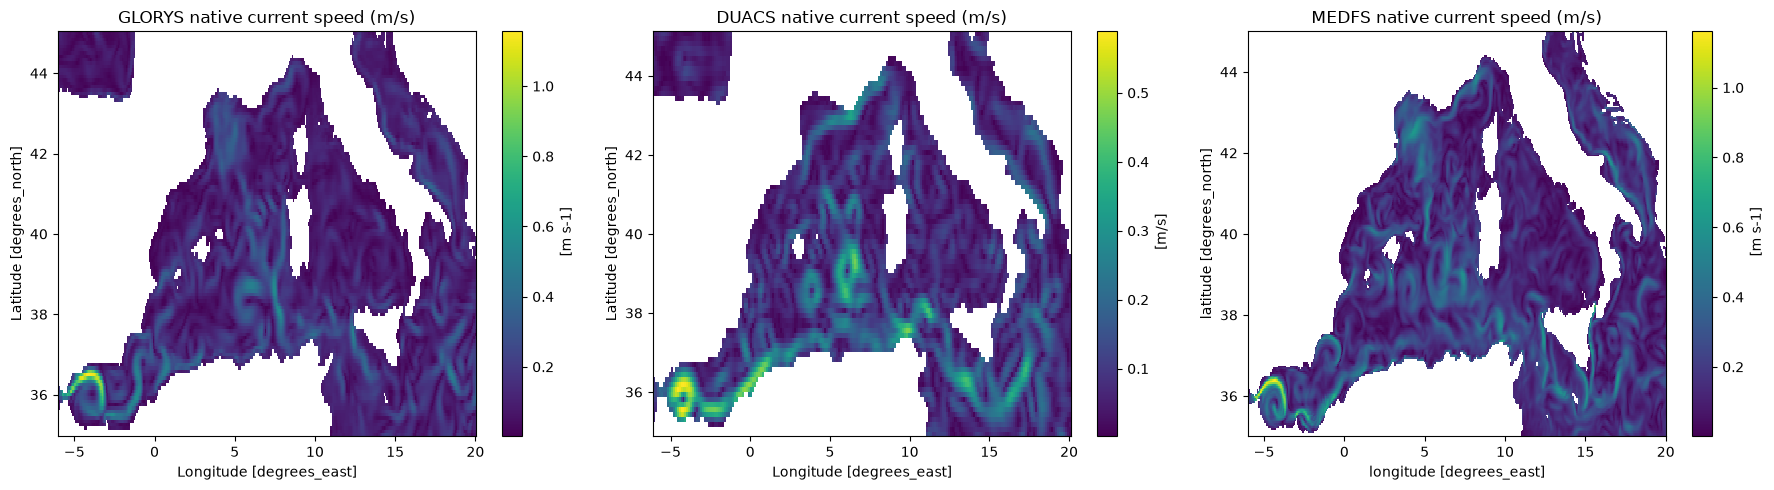

In [5]:
import math

import matplotlib.pyplot as plt
import xarray as xr


def native_surface_speed(path, u_name, v_name):
    with xr.open_dataset(path) as ds:
        speed = (ds[u_name] ** 2 + ds[v_name] ** 2) ** 0.5
        for dim in list(speed.dims):
            if dim in ("depth", "depthu", "depthv"):
                speed = speed.dropna(dim, how="all").isel({dim: 0})
            elif dim not in ("latitude", "longitude", "lat", "lon"):
                speed = speed.isel({dim: 0})
        return speed.load()


def coord_resolution(field, names):
    for name in names:
        if name in field.coords and field.sizes.get(name, 0) > 1:
            values = field.coords[name].values
            return float(abs(values[1] - values[0]))
    return None


native_currents = {
    "GLORYS": ("cmems_glorys_my", "uo", "vo"),
    "DUACS": ("cmems_duacs_my", "ugos", "vgos"),
    "MEDFS": ("cmems_med_currents_my", "uo", "vo"),
}
results_by_source = {item.source: item for item in result.results if item.path is not None}

ncols = min(3, len(native_currents))
nrows = math.ceil(len(native_currents) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
for ax, (name, (source, u_name, v_name)) in zip(axes.ravel(), native_currents.items()):
    speed = native_surface_speed(results_by_source[source].path, u_name, v_name)
    lat_res = coord_resolution(speed, ("latitude", "lat"))
    lon_res = coord_resolution(speed, ("longitude", "lon"))
    print(
        f"{name}: dims={speed.dims}, shape={speed.shape}, "
        f"lat_res={lat_res:.6g}°, lon_res={lon_res:.6g}°, finite={int(speed.notnull().sum())}"
    )
    speed.plot(ax=ax)
    ax.set_title(f"{name} native current speed (m/s)")
for ax in axes.ravel()[len(native_currents):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## Assemble onto a common grid

`Assembler` opens the downloaded NetCDF files and, with a non-native grid
policy, interpolates them onto a common overlapping grid. Variable names are
source-prefixed (for example `cmems_glorys_my__uo`) unless aliased.

In [6]:
assembler = collekt.Assembler(result)
aliases = {
    "cmems_glorys_my__uo": "glorys_u",
    "cmems_glorys_my__vo": "glorys_v",
    "cmems_duacs_my__ugos": "duacs_u",
    "cmems_duacs_my__vgos": "duacs_v",
    "cmems_med_currents_my__uo": "medfs_u",
    "cmems_med_currents_my__vo": "medfs_v",
}
dataset = assembler.to_xarray(
    aliases=aliases,
    grid="lowest_resolution",
    spatial_method="linear",
    time="lowest_resolution",
    temporal_method="nearest",
    time_tolerance="1h",
)
print(sorted(str(name) for name in dataset.data_vars))
dataset

['duacs_u', 'duacs_v', 'glorys_u', 'glorys_v', 'medfs_u', 'medfs_v']


<xarray.Dataset> Size: 1MB
Dimensions:    (depth: 2, latitude: 80, longitude: 208, time: 1)
Coordinates:
  * depth      (depth) float32 8B 0.494 1.018
  * latitude   (latitude) float64 640B 35.06 35.19 35.31 ... 44.69 44.81 44.94
  * longitude  (longitude) float64 2kB -5.938 -5.812 -5.688 ... 19.81 19.94
  * time       (time) datetime64[ns] 8B 2023-06-15
Data variables:
    glorys_u   (time, depth, latitude, longitude) float64 266kB nan nan ... nan
    glorys_v   (time, depth, latitude, longitude) float64 266kB nan nan ... nan
    duacs_u    (time, latitude, longitude) float64 133kB nan nan nan ... nan nan
    duacs_v    (time, latitude, longitude) float64 133kB nan nan nan ... nan nan
    medfs_u    (time, depth, latitude, longitude) float64 266kB nan nan ... nan
    medfs_v    (time, depth, latitude, longitude) float64 266kB nan nan ... nan
Attributes: (12/56)
    domain_name:                     GL12
    easting:                         longitude
    field_date:                      2021-06-30 00:00:00
    field_julian_date:               26113.0
    forecast_range:                  
    forecast_type:                   
    ...                              ...
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    collekt_grid_policy:             lowest_resolution
    collekt_spatial_method:          linear
    collekt_time_policy:             lowest_resolution
    collekt_temporal_method:         nearest

## Plot the surface-current speed

Compare the products' current-speed fields on the common grid.

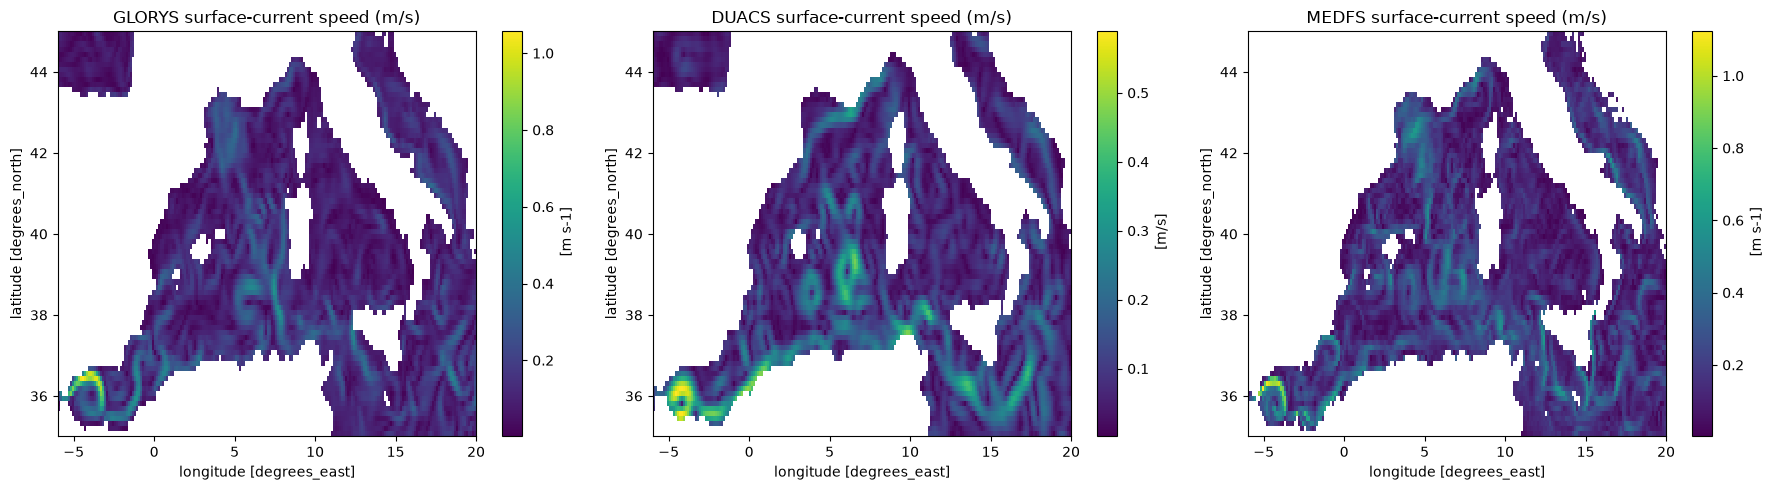

In [7]:
import matplotlib.pyplot as plt


def surface_field(field):
    for dim in list(field.dims):
        if dim == "depth":
            field = field.dropna(dim, how="all").isel({dim: 0})
        elif dim not in ("latitude", "longitude"):
            field = field.isel({dim: 0})
    return field


pairs = {
    "GLORYS": ("glorys_u", "glorys_v"),
    "DUACS": ("duacs_u", "duacs_v"),
    "MEDFS": ("medfs_u", "medfs_v"),
}
available = {name: uv for name, uv in pairs.items() if uv[0] in dataset and uv[1] in dataset}

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5), squeeze=False)
for ax, (name, (u, v)) in zip(axes[0], available.items()):
    speed = (dataset[u] ** 2 + dataset[v] ** 2) ** 0.5
    speed = surface_field(speed)
    speed.plot(ax=ax)
    ax.set_title(f"{name} surface-current speed (m/s)")
plt.tight_layout()
plt.show()